# House prices classiofication

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Loading and preparing the dataset

In [3]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
PRICE_BINS = [0, 150000, 250000, np.inf]
PRICE_LABELS = ['Budget', 'MidRange', 'Premium']

df['PriceCategory'] = pd.cut(df['SalePrice'], bins=PRICE_BINS, labels=PRICE_LABELS)

TARGET = 'PriceCategory'
CLASSES = PRICE_LABELS

print("Price segment boundaries:", PRICE_BINS)
print("\nDistribution of objects by class:")
print(df[TARGET].value_counts().reindex(CLASSES))

Price segment boundaries: [0, 150000, 250000, inf]

Distribution of objects by class:
PriceCategory
Budget      619
MidRange    624
Premium     217
Name: count, dtype: int64


## 2. Exploratory data analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   str     
 3   LotFrontage    1201 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   str     
 6   Alley          91 non-null     str     
 7   LotShape       1460 non-null   str     
 8   LandContour    1460 non-null   str     
 9   Utilities      1460 non-null   str     
 10  LotConfig      1460 non-null   str     
 11  LandSlope      1460 non-null   str     
 12  Neighborhood   1460 non-null   str     
 13  Condition1     1460 non-null   str     
 14  Condition2     1460 non-null   str     
 15  BldgType       1460 non-null   str     
 16  HouseStyle     1460 non-null   str     
 17  OverallQual    1460 non-null   int64   
 18 

In [6]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
})
missing_table

,n_missing,pct_missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [8]:
n_classes = df[TARGET].nunique()

class_counts = df[TARGET].value_counts().reindex(CLASSES)
class_share = (class_counts / len(df) * 100).round(1)
class_table = pd.DataFrame({'count': class_counts, 'share_%': class_share})
display(class_table)


,count,share_%
PriceCategory,,
Budget,619,42.4
MidRange,624,42.7
Premium,217,14.9


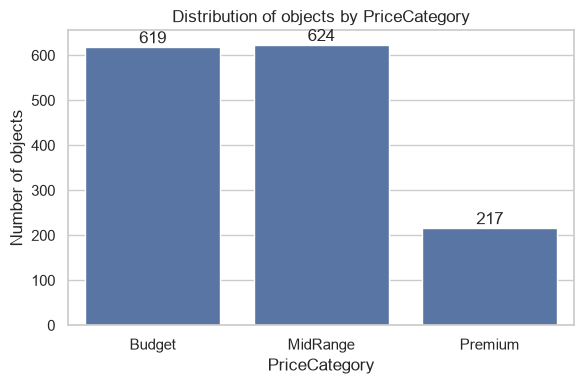

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, order=CLASSES)
plt.ylabel('Number of objects')
plt.title('Distribution of objects by PriceCategory')
for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Feature matrix X and target vector y

In [ ]:
X = df.drop(columns=['SalePrice', TARGET, 'Id'], errors='ignore').copy()
y = df[TARGET].copy()

X['MSSubClass'] = X['MSSubClass'].astype(str)

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=[str]).columns.tolist()

print(f"X: {X.shape}, y: {y.shape}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")

X: (1460, 79), y: (1460,)
Categorical features: 44
Numeric features: 35


## 4. Splitting into train, validation, and test sets

In [20]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval)

print(f"X_train: {X_train.shape} ({len(X_train)/len(X):.0%})")
print(f"X_val:   {X_val.shape} ({len(X_val)/len(X):.0%})")
print(f"X_test:  {X_test.shape} ({len(X_test)/len(X):.0%})")

prop_table = pd.DataFrame({
    'full': y.value_counts(normalize=True).reindex(CLASSES) * 100,
    'train': y_train.value_counts(normalize=True).reindex(CLASSES) * 100,
    'val': y_val.value_counts(normalize=True).reindex(CLASSES) * 100,
    'test': y_test.value_counts(normalize=True).reindex(CLASSES) * 100,
}).round(1)
prop_table

X_train: (876, 79) (60%)
X_val:   (292, 79) (20%)
X_test:  (292, 79) (20%)


,full,train,val,test
PriceCategory,,,,
Budget,42.4,42.4,42.5,42.5
MidRange,42.7,42.7,42.8,42.8
Premium,14.9,15.0,14.7,14.7


## 5. Handling missing values, encoding, and feature scaling

In [ ]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']


def build_preprocessor(X_fit_raw):
    Xf = X_fit_raw.copy()
    for col in none_means_absence:
       Xf[col] = Xf[col].fillna('None')
    
    cat_cols = Xf.select_dtypes(include=[str]).columns.tolist()
    num_cols = Xf.select_dtypes(include=[np.number]).columns.tolist()

    remaining_cat = [c for c in cat_cols if Xf[c].isna().any()]
    remaining_num = [c for c in num_cols if Xf[c].isna().any()]

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if remaining_cat:
        cat_imputer.fit(Xf[remaining_cat])
        Xf[remaining_cat] = cat_imputer.transform(Xf[remaining_cat])

    num_imputer = SimpleImputer(strategy='median')
    if remaining_num:
        num_imputer.fit(Xf[remaining_num])
        Xf[remaining_num] = num_imputer.transform(Xf[remaining_num])

    iqr_bounds = {}
    for c in num_cols:
        q1, q3 = Xf[c].quantile(0.25), Xf[c].quantile(0.75)
        iqr = q3 - q1
        iqr_bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        Xf[c] = Xf[c].clip(lower=iqr_bounds[c][0], upper=iqr_bounds[c][1])

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        ohe.fit(Xf[cat_cols])

        scaler = StandardScaler()
        scaler.fit(Xf[num_cols])


    return dict(cat_cols=cat_cols, num_cols=num_cols, 
                remaining_cat=remaining_cat, remaining_num=remaining_num, 
                cat_imputer=cat_imputer, num_imputer=num_imputer,
                iqr_bounds=iqr_bounds, ohe=ohe, scaler=scaler)


def apply_preprocessor(X_raw, prep, scale=True):
    Xr = X_raw.copy()
    for col in none_means_absence:
        Xr[col] = Xr[col].fillna('None')

    if prep['remaining_cat']:
        Xr[prep['remaining_cat']] = prep['cat_imputer'].transform(Xr[prep['remaining_cat']])
    if prep['remaining_num']:
        Xr[prep['remaining_num']] = prep['num_imputer'].transform(Xr[prep['remaining_num']])

    for c in prep['num_cols']:
        lo, hi = prep['iqr_bounds'][c]
        Xr[c] = Xr[c].clip(lower=lo, upper=hi)

    X_cat = pd.DataFrame(
        prep['ohe'].transform(Xr[prep['cat_cols']]),
        columns=prep['ohe'].get_feature_names_out(prep['cat_cols']),
        index=Xr.index
    )
    if scale:
        X_num = pd.DataFrame(
            prep['scaler'].transform(Xr[prep['num_cols']]),
            columns=prep['num_cols'],
            index=Xr.index
        )
    else:
        X_num = Xr[prep['num_cols']].reset_index(drop=True)
        X_num.index = Xr.index
    
    return pd.concat([X_num, X_cat], axis=1)

In [23]:
prep = build_preprocessor(X_train)

X_train_final = apply_preprocessor(X_train, prep)
X_val_final = apply_preprocessor(X_val, prep)
X_test_final = apply_preprocessor(X_test, prep)

y_train_final = y_train.reset_index(drop=True)
y_val_final = y_val.reset_index(drop=True)
y_test_final = y_test.reset_index(drop=True)
X_train_final = X_train_final.reset_index(drop=True)
X_val_final = X_val_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)

print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")

X_train_final: (876, 304)
X_val_final:   (292, 304)
X_test_final:  (292, 304)


In [24]:
print('Numerical features before scaling (train), mean / std:')
display(X_train[prep['num_cols']].agg(['mean', 'std']).T.head())

print('After standardization (train), mean / std:')
display(X_train_final[prep['num_cols']].agg(['mean', 'std']).T.head())

Numerical features before scaling (train), mean / std:


,mean,std
LotFrontage,71.047420,25.317492
LotArea,10595.855023,10219.993453
OverallQual,6.113014,1.349629
OverallCond,5.638128,1.114213
YearBuilt,1971.107306,29.968324


After standardization (train), mean / std:


,mean,std
LotFrontage,1.764190e-16,1.000571
LotArea,9.733462e-17,1.000571
OverallQual,2.169751e-16,1.000571
OverallCond,-1.095014e-16,1.000571
YearBuilt,-6.529531e-16,1.000571
